# Policy Stringency Index — Data Preparation and Panel Construction

This notebook prepares the Oxford COVID-19 Government Response Tracker (OxCGRT) subnational dataset for the United States.
It extracts the state-level Stringency Index and constructs a clean State–Date panel dataset for integration into the Capstone project.

#### Data source:
- Oxford COVID-19 Government Response Tracker (OxCGRT), Blavatnik School of Government, University of Oxford
Subnational dataset (United States)

- https://raw.githubusercontent.com/OxCGRT/covid-policy-dataset/main/data/OxCGRT_compact_subnational_v1.csv

#### What is the COVID-19 Stringency Index?
The Stringency Index is a composite indicator that measures the strictness of government responses to COVID-19. It was developed by the Oxford COVID-19 Government Response Tracker (OxCGRT) and is calculated from nine policy response indicators related to containment and closure measures.

- These indicators include:
- school closures
- workplace closures
- cancellation of public events
- restrictions on gatherings
- public transport closures
- stay-at-home requirements
- public information campaigns
- internal movement restrictions
- international travel controls

Each component is rescaled to a value between 0 and 100, and the overall index is computed as their average, producing a final score from 0 (no restrictions) to 100 (maximum stringency). A higher value indicates a stricter government response.

Importantly, the index measures the strictness of policies, not their effectiveness or the level of public compliance.


#### Reference:
Hale, T., Angrist, N., Goldszmidt, R. et al. (2021).
A global panel database of pandemic policies (Oxford COVID-19 Government Response Tracker).
Nature Human Behaviour.
- https://www.bsg.ox.ac.uk/research/covid-19-government-response-tracker
- https://ourworldindata.org/metrics-explained-covid19-stringency-index?utm_source=chatgpt.com

In [1]:
import prettytable
import sqlite3
import requests
import pandas as pd
import matplotlib.pyplot as plt

prettytable.DEFAULT = 'DEFAULT'

In [2]:
# --- PATH CONFIG  ---
from pathlib import Path

current = Path().resolve()
while current != current.parent:
    if (current / "Data").exists():
        PROJECT_ROOT = current
        break
    current = current.parent

DATA_RAW = PROJECT_ROOT / "Data" / "Raw"
DATA_CLEAN = PROJECT_ROOT / "Data" / "Cleaned"
DATA_PROCESSED = PROJECT_ROOT / "Data" / "Processed"
DB_PATH = PROJECT_ROOT / "Capstone.db"

print("Project root:", PROJECT_ROOT)

Project root: /Users/emerino/Documents/Capstone_Project_Group_4-


## 1) Load raw OxCGRT dataset

In [3]:
# Raw Oxford dataset (subnational level)
url = "https://raw.githubusercontent.com/OxCGRT/covid-policy-dataset/main/data/OxCGRT_compact_subnational_v1.csv"

df = pd.read_csv(url, low_memory=False)

print("Rows:", len(df))
df.head()

Rows: 239661


,CountryName,CountryCode,RegionName,RegionCode,CityName,CityCode,Jurisdiction,Date,C1M_School.closing,C1M_Flag,...,V3_Vaccine.Financial.Support..summary.,V4_Mandatory.Vaccination..summary.,ConfirmedCases,ConfirmedDeaths,MajorityVaccinated,PopulationVaccinated,StringencyIndex_Average,GovernmentResponseIndex_Average,ContainmentHealthIndex_Average,EconomicSupportIndex
0,Australia,AUS,NaN,NaN,NaN,NaN,NAT_TOTAL,20200101,0,NaN,...,0,NaN,0.0,0.0,NV,0,0.0,0.0,0.0,0.0
1,Australia,AUS,NaN,NaN,NaN,NaN,NAT_TOTAL,20200102,0,NaN,...,0,NaN,0.0,0.0,NV,0,0.0,0.0,0.0,0.0
2,Australia,AUS,NaN,NaN,NaN,NaN,NAT_TOTAL,20200103,0,NaN,...,0,NaN,0.0,0.0,NV,0,0.0,0.0,0.0,0.0
3,Australia,AUS,NaN,NaN,NaN,NaN,NAT_TOTAL,20200104,0,NaN,...,0,NaN,0.0,0.0,NV,0,0.0,0.0,0.0,0.0
4,Australia,AUS,NaN,NaN,NaN,NaN,NAT_TOTAL,20200105,0,NaN,...,0,NaN,0.0,0.0,NV,0,0.0,0.0,0.0,0.0


## 2) Filter United States and state-level observations

In [4]:
# Keep United States only
df_us = df[df["CountryName"] == "United States"]

# Keep state-level only
df_states = df_us[df_us["Jurisdiction"] == "STATE_TOTAL"].copy()

print("US rows:", len(df_us))
print("State rows:", len(df_states))

US rows: 56992
State rows: 55896


## 3) Convert date and identify Stringency variable

In [5]:
# Convert Date to datetime
df_states["Date"] = pd.to_datetime(df_states["Date"], format="%Y%m%d")

# Identify Stringency column dynamically
stringency_cols = [c for c in df_states.columns if "Stringency" in c]
print("Stringency columns:", stringency_cols)

stringency_column = stringency_cols[0]


Stringency columns: ['StringencyIndex_Average']


## 4) Select relevant variables and clean

In [6]:
df_states = df_states[[
    "RegionName",
    "Date",
    stringency_column
]].rename(columns={
    "RegionName": "state",
    stringency_column: "StringencyIndex"
})

df_states = df_states.sort_values(["state", "Date"]).reset_index(drop=True)

df_states.head()


,state,Date,StringencyIndex
0,Alabama,2020-01-01,0.0
1,Alabama,2020-01-02,0.0
2,Alabama,2020-01-03,0.0
3,Alabama,2020-01-04,0.0
4,Alabama,2020-01-05,0.0


## 5) Evolution of the Monthly COVID-19 Stringency Index Across U.S. States

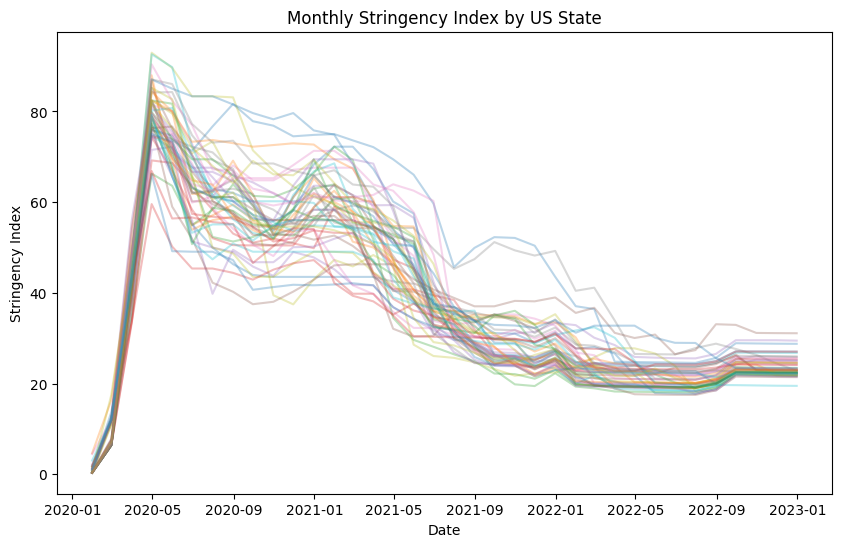

In [7]:
df_plot = (df_states.set_index("Date").groupby("state")["StringencyIndex"].resample("ME").mean().reset_index())

plt.figure(figsize=(10,6))

for state, data in df_plot.groupby("state"):
    plt.plot(data["Date"], data["StringencyIndex"], alpha=0.3)

plt.title("Monthly Stringency Index by US State")
plt.xlabel("Date")
plt.ylabel("Stringency Index")
plt.show()

## 6) U.S. Average Monthly Stringency Index (2020–2022)

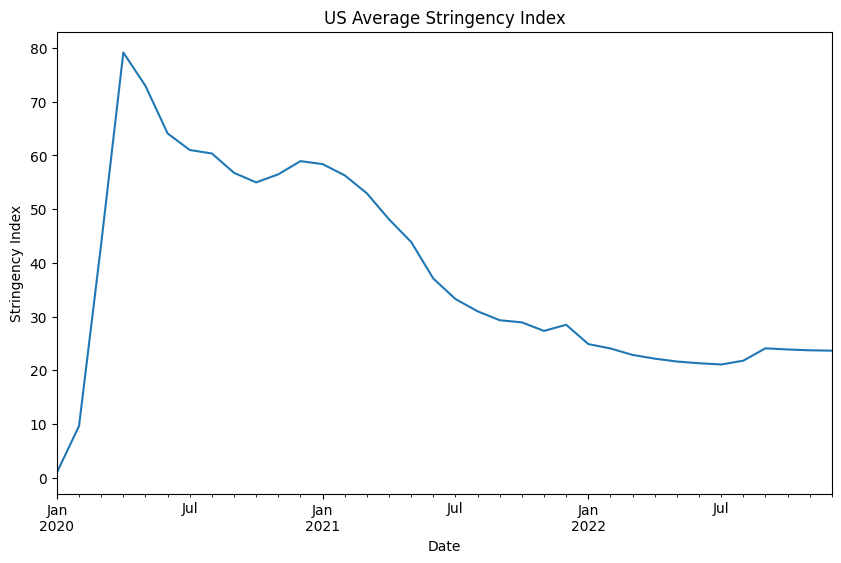

In [8]:
national = (df_states.set_index("Date").groupby("state")["StringencyIndex"].resample("ME").mean().reset_index().groupby("Date")["StringencyIndex"].mean())

national.plot(figsize=(10,6), title="US Average Stringency Index")
plt.ylabel("Stringency Index")
plt.show()


State-Level Monthly Stringency Index – Selected U.S. States (2020–2022)

## 7) State-Level Monthly Stringency Index – Selected U.S. States (2020–2022)

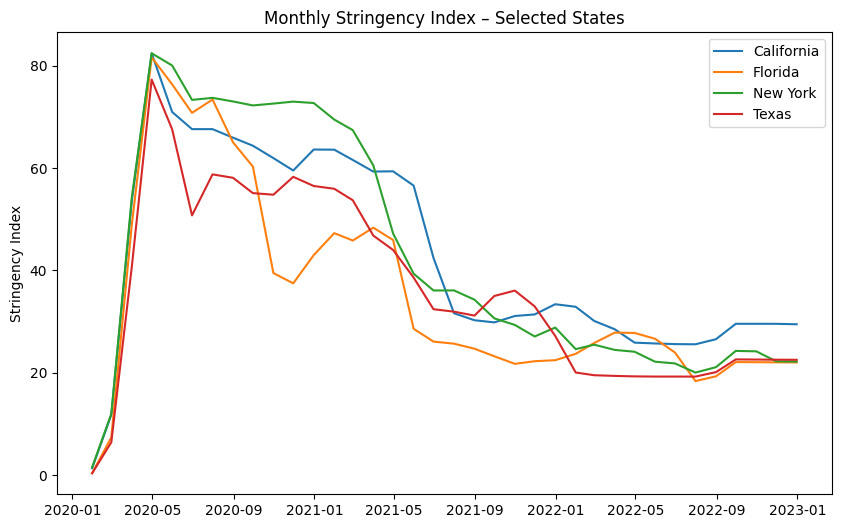

In [9]:
states_sel = ["California", "Texas", "New York", "Florida"]

df_sel = df_plot[df_plot["state"].isin(states_sel)]

plt.figure(figsize=(10,6))

for state, data in df_sel.groupby("state"):
    plt.plot(data["Date"], data["StringencyIndex"], label=state)

plt.legend()
plt.title("Monthly Stringency Index – Selected States")
plt.ylabel("Stringency Index")
plt.show()


## 8) Aggregate daily stringency to monthly level
The OxCGRT Stringency Index is reported daily. For panel consistency with other monthly datasets (e.g., unemployment), the index is aggregated to the state–year–month level using the monthly mean. The Stringency Index is defined by the Oxford COVID-19 Government Response Tracker as a composite measure of the strictness of government policies over time, where higher or lower values reflect genuine policy changes rather than measurement error (Hale et al., OxCGRT). Therefore, extreme daily values are retained and not treated as outliers. The monthly mean preserves the average policy intensity implemented within each state during each month and is consistent with the interpretation and construction of the Oxford Stringency Index.

In [10]:
# Ensure Date column is in datetime format
df_states["Date"] = pd.to_datetime(df_states["Date"])

# Extract year and month from the Date column
df_states["year"] = df_states["Date"].dt.year
df_states["month"] = df_states["Date"].dt.month

# Aggregate daily StringencyIndex to monthly average per state
df_monthly = (
    df_states
    .groupby(["state", "year", "month"], as_index=False)
    .agg({"StringencyIndex": "mean"})
)

# Round the index to 2 decimal places
df_monthly["StringencyIndex"] = df_monthly["StringencyIndex"].round(2)

# Preview result
df_monthly.head()

,state,year,month,StringencyIndex
0,Alabama,2020,1,0.36
1,Alabama,2020,2,6.80
2,Alabama,2020,3,39.95
3,Alabama,2020,4,78.94
4,Alabama,2020,5,65.65


## 9) Validate panel completeness

After aggregating daily Stringency Index values to the monthly level, the dataset contains no missing observations.
Therefore, no imputation or interpolation is required.

In [11]:
df_monthly = df_monthly[~df_monthly["state"].isin(["Washington DC", "District Of Columbia"])]

# Check missing values
missing = df_monthly.isna().sum()
print("Missing values:\n", missing)

# Panel structure
n_states = df_monthly["state"].nunique()
n_periods = df_monthly[["year","month"]].drop_duplicates().shape[0]

print("States:", n_states)
print("Periods:", n_periods)
print("Expected rows:", n_states * n_periods)
print("Actual rows:", len(df_monthly))


Missing values:
 state              0
year               0
month              0
StringencyIndex    0
dtype: int64
States: 50
Periods: 36
Expected rows: 1800
Actual rows: 1800


## 10) Export clean monthly policy panel

In [12]:
# Remove Idaho

# Export cleaned dataset to Cleaned folder

EXCLUDED_STATES = ["Idaho", "Wyoming"]
df_monthly = df_monthly[~df_monthly["state"].isin(EXCLUDED_STATES)]

output_path = DATA_CLEAN / "policy_stringency_state_month_2020_2022.csv"
df_monthly.to_csv(output_path, index=False)

print(f"Saved: {output_path}")

Saved: /Users/emerino/Documents/Capstone_Project_Group_4-/Data/Cleaned/policy_stringency_state_month_2020_2022.csv


## 11) Load into SQLite database

In [13]:
# Connect to SQLite in project root
con = sqlite3.connect(PROJECT_ROOT / "Capstone.db")
cur = con.cursor()
%load_ext sql
%sql sqlite:///{PROJECT_ROOT}/Capstone.db

df = pd.read_csv(DATA_CLEAN / "policy_stringency_state_month_2020_2022.csv")
df.to_sql("Policy", con, if_exists='replace', index=False, method="multi")

print("Policy table loaded from Cleaned folder")

Policy table loaded from Cleaned folder


## 12) Validate database ingestion

In [14]:
%sql SELECT * FROM Policy LIMIT 5;

 * sqlite:////Users/emerino/Documents/Capstone_Project_Group_4-/Capstone.db
Done.


state,year,month,StringencyIndex
Alabama,2020,1,0.36
Alabama,2020,2,6.8
Alabama,2020,3,39.95
Alabama,2020,4,78.94
Alabama,2020,5,65.65


In [15]:
%%sql SELECT COUNT(DISTINCT state) AS num_states
FROM Policy;

 * sqlite:////Users/emerino/Documents/Capstone_Project_Group_4-/Capstone.db
Done.


num_states
48


In [16]:
%%sql SELECT DISTINCT state
FROM Policy
ORDER BY state;

 * sqlite:////Users/emerino/Documents/Capstone_Project_Group_4-/Capstone.db
Done.


state
Alabama
Alaska
Arizona
Arkansas
California
Colorado
Connecticut
Delaware
Florida
Georgia
